In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df=sns.load_dataset('titanic')

In [4]:
df.sample(4)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
511,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
531,0,3,male,NaN,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
589,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False


In [5]:
df['age']=df['age'].fillna(df['age'].median())

In [16]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [12]:
df.drop(columns=['deck'],inplace=True)

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

<Axes: xlabel='fare'>

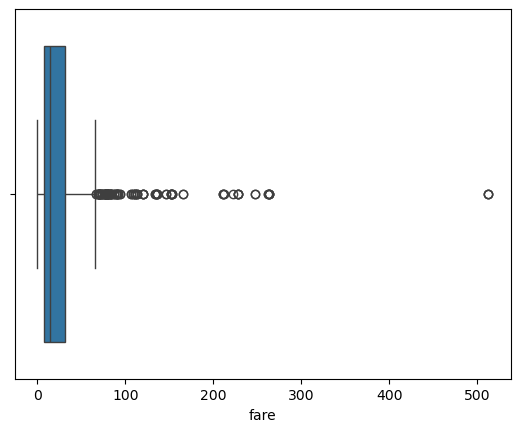

In [17]:
sns.boxplot(x=df['fare'])

In [19]:
q1=df['fare'].quantile(0.25)
q3=df['fare'].quantile(0.75)

In [22]:
IQR=q3-q1

In [23]:
IQR

np.float64(23.0896)

In [24]:
lower = q1 - 1.5 * IQR

upper = q3 + 1.5 * IQR

In [25]:
lower

np.float64(-26.724)

In [26]:
upper

np.float64(65.6344)

In [28]:
outliers = df[
    (df['fare'] < lower) |
    (df['fare'] > upper)
]

print(outliers.shape)

(116, 14)
